## 📚 Setup and Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import os
import sys
import yaml
import pickle
import warnings
from pathlib import Path
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag
import textstat
from collections import Counter
import re
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

# Add src to path
sys.path.append('../')

print("✅ Libraries imported successfully!")
print(f"Current directory: {os.getcwd()}")

✅ Libraries imported successfully!
Current directory: d:\Projects\Human-vs-AI-Classifier\notebooks


In [2]:
# Download required NLTK data
nltk_packages = ['punkt', 'stopwords', 'averaged_perceptron_tagger', 'wordnet']

print("📥 Downloading NLTK data...")
for package in nltk_packages:
    try:
        nltk.download(package, quiet=True)
    except Exception as e:
        print(f"⚠️  Error downloading {package}: {e}")

print("✅ NLTK data ready!")

📥 Downloading NLTK data...
✅ NLTK data ready!


In [5]:
# Load configuration
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("📋 Configuration loaded:")
print(f"  TF-IDF max features: {config['features']['tfidf']['max_features']}")
print(f"  TF-IDF ngram range: {config['features']['tfidf']['ngram_range']}")
print(f"  Features will be saved to: data/features/")

📋 Configuration loaded:
  TF-IDF max features: 5000
  TF-IDF ngram range: [1, 3]
  Features will be saved to: data/features/


## 📂 Load Processed Data

In [6]:
print("📂 Loading processed datasets...\n")

# Load datasets
train_df = pd.read_csv(config['data']['train_file'])
val_df = pd.read_csv(config['data']['val_file'])
test_df = pd.read_csv(config['data']['test_file'])

print(f"✅ Datasets loaded!")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")

# Display sample
print("\n📊 Sample data:")
display(train_df.head(3))

📂 Loading processed datasets...

✅ Datasets loaded!
   Training:   36,716 samples
   Validation: 7,868 samples
   Test:       7,868 samples

📊 Sample data:


,text,label
0,"Yes, human colonization of other planets is de...",1
1,Prurigo nodularis is a skin condition that cau...,1
2,"Christian Bale played Batman in ""The Dark Knig...",1


In [7]:
# Load metadata
metadata_path = os.path.join(config['data']['processed_path'], 'metadata.json')
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print("📋 Dataset Metadata:")
for key, value in metadata.items():
    print(f"   {key}: {value}")

📋 Dataset Metadata:
   total_samples: 52452
   train_samples: 36716
   val_samples: 7868
   test_samples: 7868
   train_ratio: 0.7
   val_ratio: 0.15
   test_ratio: 0.15
   num_classes: 2
   class_names: ['Human', 'AI']
   balanced: True
   min_length: 50
   random_state: 42
   sources: ['hc3_chatgpt', 'hc3_human', 'synthetic_ai', 'synthetic_human']


## 🔤 Feature 1: TF-IDF Features

In [8]:
print("🔤 Extracting TF-IDF features...\n")

# Initialize TF-IDF Vectorizer
tfidf_config = config['features']['tfidf']

tfidf_vectorizer = TfidfVectorizer(
    max_features=tfidf_config['max_features'],
    ngram_range=tuple(tfidf_config['ngram_range']),
    min_df=tfidf_config['min_df'],
    max_df=tfidf_config['max_df'],
    sublinear_tf=True,
    strip_accents='unicode'
)

print(f"TF-IDF Configuration:")
print(f"   Max features: {tfidf_config['max_features']}")
print(f"   N-gram range: {tfidf_config['ngram_range']}")
print(f"   Min DF: {tfidf_config['min_df']}")
print(f"   Max DF: {tfidf_config['max_df']}")

# Fit on training data
print("\n⏳ Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text'])

# Transform validation and test data
print("⏳ Transforming validation and test data...")
X_val_tfidf = tfidf_vectorizer.transform(val_df['text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text'])

print(f"\n✅ TF-IDF features extracted!")
print(f"   Training shape:   {X_train_tfidf.shape}")
print(f"   Validation shape: {X_val_tfidf.shape}")
print(f"   Test shape:       {X_test_tfidf.shape}")
print(f"   Vocabulary size:  {len(tfidf_vectorizer.vocabulary_):,}")

🔤 Extracting TF-IDF features...

TF-IDF Configuration:
   Max features: 5000
   N-gram range: [1, 3]
   Min DF: 2
   Max DF: 0.95

⏳ Fitting TF-IDF on training data...
⏳ Transforming validation and test data...

✅ TF-IDF features extracted!
   Training shape:   (36716, 5000)
   Validation shape: (7868, 5000)
   Test shape:       (7868, 5000)
   Vocabulary size:  5,000


In [9]:
# Analyze top TF-IDF features
print("📊 Top 20 TF-IDF features:\n")

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF scores for each class
y_train = train_df['label'].values

# Human texts (label=0)
human_tfidf = X_train_tfidf[y_train == 0].mean(axis=0).A1
human_top_indices = human_tfidf.argsort()[-20:][::-1]
human_top_features = [(feature_names[i], human_tfidf[i]) for i in human_top_indices]

print("Top features for HUMAN text:")
for i, (feature, score) in enumerate(human_top_features[:10], 1):
    print(f"   {i:2d}. {feature:20s} - {score:.4f}")

# AI texts (label=1)
ai_tfidf = X_train_tfidf[y_train == 1].mean(axis=0).A1
ai_top_indices = ai_tfidf.argsort()[-20:][::-1]
ai_top_features = [(feature_names[i], ai_tfidf[i]) for i in ai_top_indices]

print("\nTop features for AI text:")
for i, (feature, score) in enumerate(ai_top_features[:10], 1):
    print(f"   {i:2d}. {feature:20s} - {score:.4f}")

📊 Top 20 TF-IDF features:

Top features for HUMAN text:
    1. the                  - 0.0579
    2. to                   - 0.0437
    3. you                  - 0.0404
    4. of                   - 0.0395
    5. and                  - 0.0390
    6. is                   - 0.0369
    7. it                   - 0.0366
    8. in                   - 0.0328
    9. that                 - 0.0313
   10. they                 - 0.0255

Top features for AI text:
    1. the                  - 0.0544
    2. to                   - 0.0490
    3. and                  - 0.0489
    4. of                   - 0.0441
    5. is                   - 0.0409
    6. in                   - 0.0375
    7. that                 - 0.0363
    8. it                   - 0.0363
    9. or                   - 0.0342
   10. can                  - 0.0324


## 📊 Feature 2: Statistical Features

In [10]:
def calculate_entropy(text):
    """Calculate Shannon entropy of text."""
    if not text or len(text) == 0:
        return 0.0
    
    # Character-level entropy
    char_counts = Counter(text.lower())
    total_chars = sum(char_counts.values())
    probabilities = [count / total_chars for count in char_counts.values()]
    
    return entropy(probabilities, base=2)

def calculate_burstiness(text):
    """Calculate burstiness of text (variation in word usage)."""
    if not text:
        return 0.0
    
    words = text.lower().split()
    if len(words) < 2:
        return 0.0
    
    word_counts = Counter(words)
    counts = list(word_counts.values())
    
    mean_count = np.mean(counts)
    std_count = np.std(counts)
    
    if mean_count == 0:
        return 0.0
    
    return (std_count - mean_count) / (std_count + mean_count)

def calculate_type_token_ratio(text):
    """Calculate type-token ratio (vocabulary diversity)."""
    if not text:
        return 0.0
    
    words = text.lower().split()
    if len(words) == 0:
        return 0.0
    
    unique_words = len(set(words))
    total_words = len(words)
    
    return unique_words / total_words

def extract_statistical_features(df):
    """Extract all statistical features from dataframe."""
    print("   Calculating entropy...")
    df['entropy'] = df['text'].progress_apply(calculate_entropy)
    
    print("   Calculating burstiness...")
    df['burstiness'] = df['text'].progress_apply(calculate_burstiness)
    
    print("   Calculating type-token ratio...")
    df['ttr'] = df['text'].progress_apply(calculate_type_token_ratio)
    
    print("   Calculating text statistics...")
    df['char_count'] = df['text'].apply(len)
    df['word_count'] = df['text'].apply(lambda x: len(x.split()))
    df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0)
    df['sentence_count'] = df['text'].apply(lambda x: len(re.split(r'[.!?]+', x)))
    df['avg_sentence_length'] = df['word_count'] / df['sentence_count'].replace(0, 1)
    
    return df

print("📊 Extracting statistical features...\n")
print("Processing training data...")
train_df = extract_statistical_features(train_df.copy())

print("\nProcessing validation data...")
val_df = extract_statistical_features(val_df.copy())

print("\nProcessing test data...")
test_df = extract_statistical_features(test_df.copy())

print("\n✅ Statistical features extracted!")

📊 Extracting statistical features...

Processing training data...
   Calculating entropy...


  0%|          | 0/36716 [00:00<?, ?it/s]

   Calculating burstiness...


  0%|          | 0/36716 [00:00<?, ?it/s]

   Calculating type-token ratio...


...

   Calculating burstiness...


  0%|          | 0/7868 [00:00<?, ?it/s]

   Calculating type-token ratio...


  0%|          | 0/7868 [00:00<?, ?it/s]

   Calculating text statistics...

✅ Statistical features extracted!


In [11]:
# Display statistical features
stat_features = ['entropy', 'burstiness', 'ttr', 'char_count', 'word_count', 
                 'avg_word_length', 'sentence_count', 'avg_sentence_length']

print("📊 Statistical Features Summary:\n")
print("Training Data:")
display(train_df.groupby('label')[stat_features].mean())

print("\n📈 Feature Distributions by Class:")
for feature in ['entropy', 'burstiness', 'ttr']:
    print(f"\n{feature.upper()}:")
    print(f"  Human (0): {train_df[train_df['label']==0][feature].mean():.4f} ± {train_df[train_df['label']==0][feature].std():.4f}")
    print(f"  AI (1):    {train_df[train_df['label']==1][feature].mean():.4f} ± {train_df[train_df['label']==1][feature].std():.4f}")

📊 Statistical Features Summary:

Training Data:


,entropy,burstiness,ttr,char_count,word_count,avg_word_length,sentence_count,avg_sentence_length
label,,,,,,,,
0,4.141459,-0.220580,0.692247,692.296220,136.067545,4.104231,7.836910,16.301116
1,4.170941,-0.027477,0.565058,1013.886807,173.910992,4.853296,9.171043,19.211362



📈 Feature Distributions by Class:

ENTROPY:
  Human (0): 4.1415 ± 0.1139
  AI (1):    4.1709 ± 0.0698

BURSTINESS:
  Human (0): -0.2206 ± 0.2642
  AI (1):    -0.0275 ± 0.1282

TTR:
  Human (0): 0.6922 ± 0.1546
  AI (1):    0.5651 ± 0.0892


## 📝 Feature 3: Linguistic Features

In [12]:
def extract_linguistic_features(df):
    """Extract linguistic features using textstat and NLTK."""
    
    print("   Calculating readability scores...")
    # Readability scores
    df['flesch_reading_ease'] = df['text'].progress_apply(lambda x: textstat.flesch_reading_ease(x) if x else 0)
    df['flesch_kincaid_grade'] = df['text'].progress_apply(lambda x: textstat.flesch_kincaid_grade(x) if x else 0)
    df['gunning_fog'] = df['text'].progress_apply(lambda x: textstat.gunning_fog(x) if x else 0)
    df['automated_readability_index'] = df['text'].progress_apply(lambda x: textstat.automated_readability_index(x) if x else 0)
    df['coleman_liau_index'] = df['text'].progress_apply(lambda x: textstat.coleman_liau_index(x) if x else 0)
    
    print("   Calculating syllable counts...")
    df['syllable_count'] = df['text'].progress_apply(lambda x: textstat.syllable_count(x) if x else 0)
    df['avg_syllables_per_word'] = df['syllable_count'] / df['word_count'].replace(0, 1)
    
    print("   Calculating punctuation features...")
    df['punctuation_count'] = df['text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
    df['punctuation_ratio'] = df['punctuation_count'] / df['char_count'].replace(0, 1)
    
    print("   Calculating uppercase features...")
    df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
    df['uppercase_ratio'] = df['uppercase_count'] / df['char_count'].replace(0, 1)
    
    print("   Calculating digit features...")
    df['digit_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))
    df['digit_ratio'] = df['digit_count'] / df['char_count'].replace(0, 1)
    
    return df

print("📝 Extracting linguistic features...\n")
print("Processing training data...")
train_df = extract_linguistic_features(train_df)

print("\nProcessing validation data...")
val_df = extract_linguistic_features(val_df)

print("\nProcessing test data...")
test_df = extract_linguistic_features(test_df)

print("\n✅ Linguistic features extracted!")

📝 Extracting linguistic features...

Processing training data...
   Calculating readability scores...


  0%|          | 0/36716 [00:00<?, ?it/s]

  0%|          | 0/36716 [00:00<?, ?it/s]

  0%|          | 0/36716 [00:00<?, ?it/s]

  0%|          | 0/36716 [00:00<?, ?it/s]

...

  0%|          | 0/7868 [00:00<?, ?it/s]

  0%|          | 0/7868 [00:00<?, ?it/s]

   Calculating syllable counts...


  0%|          | 0/7868 [00:00<?, ?it/s]

   Calculating punctuation features...
   Calculating uppercase features...
   Calculating digit features...

✅ Linguistic features extracted!


In [13]:
# Display linguistic features
ling_features = ['flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog',
                 'automated_readability_index', 'coleman_liau_index', 'avg_syllables_per_word',
                 'punctuation_ratio', 'uppercase_ratio', 'digit_ratio']

print("📝 Linguistic Features Summary:\n")
print("Training Data:")
display(train_df.groupby('label')[ling_features].mean())

📝 Linguistic Features Summary:

Training Data:


,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,automated_readability_index,coleman_liau_index,avg_syllables_per_word,punctuation_ratio,uppercase_ratio,digit_ratio
label,,,,,,,,,
0,62.864620,9.113377,11.589284,7.204237,8.119381,1.312856,0.031917,0.021635,0.005125
1,51.997073,11.544297,14.124152,12.574145,10.209398,1.561981,0.022418,0.016014,0.002975


## 🔗 Combine All Features

In [14]:
print("🔗 Combining all features...\n")

# Define feature columns
handcrafted_features = stat_features + ling_features

print(f"Total handcrafted features: {len(handcrafted_features)}")
print(f"Features: {handcrafted_features}")

# Extract handcrafted features
X_train_handcrafted = train_df[handcrafted_features].values
X_val_handcrafted = val_df[handcrafted_features].values
X_test_handcrafted = test_df[handcrafted_features].values

print(f"\nHandcrafted features shape:")
print(f"   Training:   {X_train_handcrafted.shape}")
print(f"   Validation: {X_val_handcrafted.shape}")
print(f"   Test:       {X_test_handcrafted.shape}")

# Scale handcrafted features
print("\n⏳ Scaling handcrafted features...")
scaler = StandardScaler()
X_train_handcrafted_scaled = scaler.fit_transform(X_train_handcrafted)
X_val_handcrafted_scaled = scaler.transform(X_val_handcrafted)
X_test_handcrafted_scaled = scaler.transform(X_test_handcrafted)

print("✅ Features scaled!")

🔗 Combining all features...

Total handcrafted features: 17
Features: ['entropy', 'burstiness', 'ttr', 'char_count', 'word_count', 'avg_word_length', 'sentence_count', 'avg_sentence_length', 'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'automated_readability_index', 'coleman_liau_index', 'avg_syllables_per_word', 'punctuation_ratio', 'uppercase_ratio', 'digit_ratio']

Handcrafted features shape:
   Training:   (36716, 17)
   Validation: (7868, 17)
   Test:       (7868, 17)

⏳ Scaling handcrafted features...
✅ Features scaled!


In [15]:
# Combine TF-IDF and handcrafted features
print("🔗 Combining TF-IDF and handcrafted features...\n")

from scipy.sparse import hstack, csr_matrix

# Combine features
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_handcrafted_scaled)])
X_val_combined = hstack([X_val_tfidf, csr_matrix(X_val_handcrafted_scaled)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(X_test_handcrafted_scaled)])

print(f"✅ Combined features created!")
print(f"   Training:   {X_train_combined.shape}")
print(f"   Validation: {X_val_combined.shape}")
print(f"   Test:       {X_test_combined.shape}")
print(f"\n   TF-IDF features:      {X_train_tfidf.shape[1]}")
print(f"   Handcrafted features: {X_train_handcrafted_scaled.shape[1]}")
print(f"   Total features:       {X_train_combined.shape[1]}")

🔗 Combining TF-IDF and handcrafted features...

✅ Combined features created!
   Training:   (36716, 5017)
   Validation: (7868, 5017)
   Test:       (7868, 5017)

   TF-IDF features:      5000
   Handcrafted features: 17
   Total features:       5017


## 📊 Feature Analysis

📊 Visualizing feature distributions...



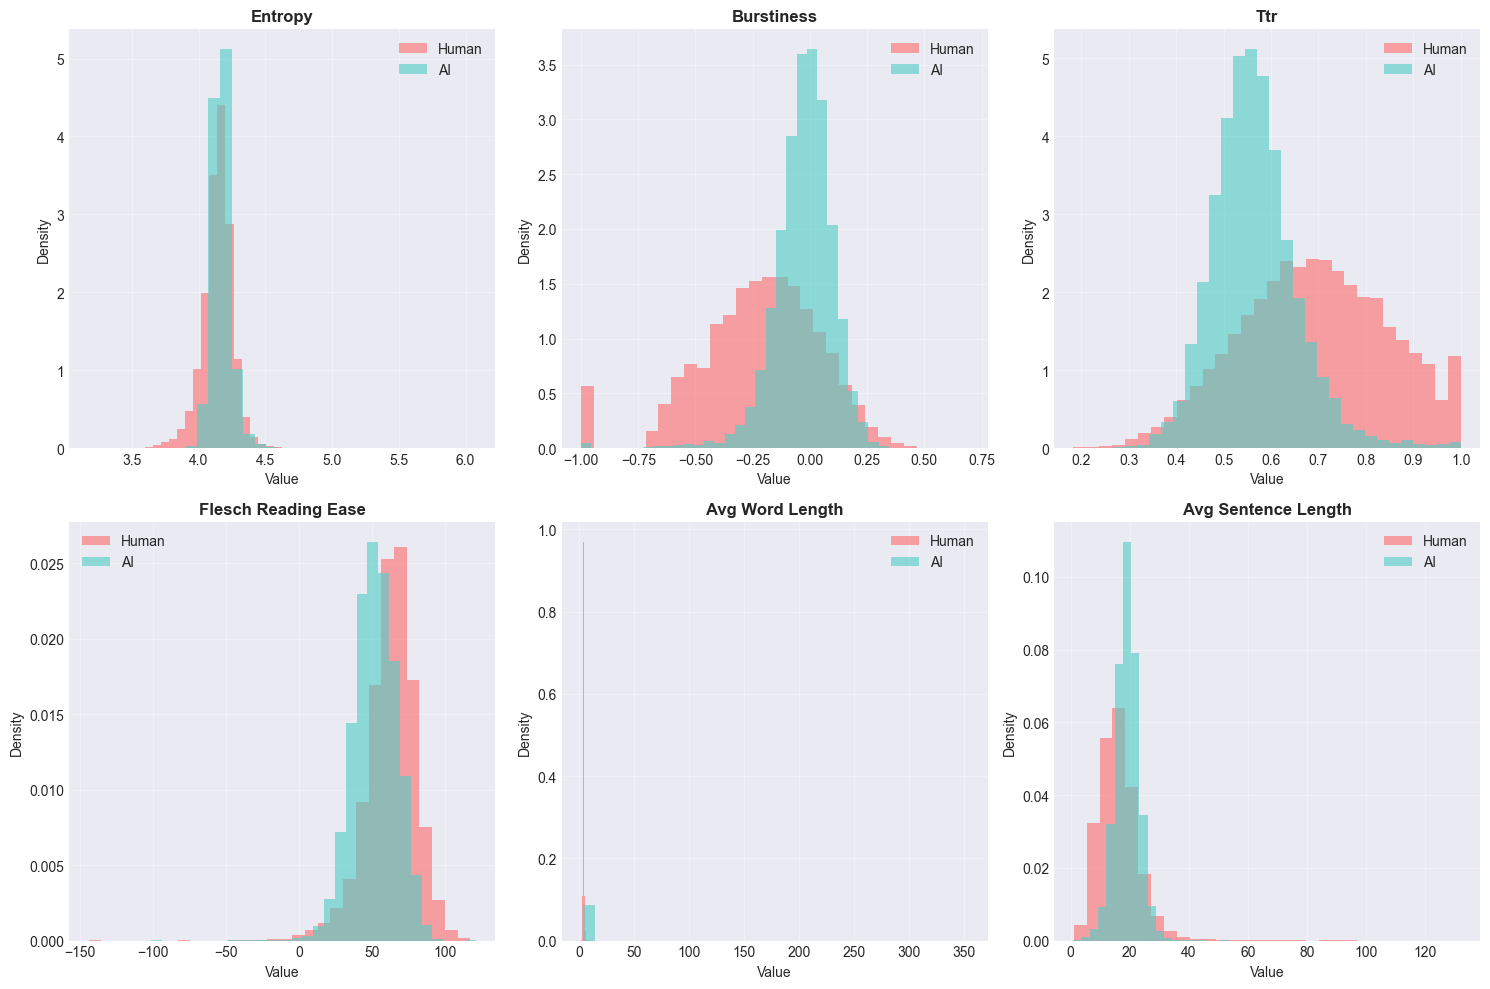

✅ Visualizations complete!


In [16]:
# Visualize feature distributions
print("📊 Visualizing feature distributions...\n")

# Select key features to visualize
key_features = ['entropy', 'burstiness', 'ttr', 'flesch_reading_ease', 
                'avg_word_length', 'avg_sentence_length']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    # Plot distributions for both classes
    train_df[train_df['label'] == 0][feature].hist(ax=axes[idx], alpha=0.6, bins=30, 
                                                     label='Human', color='#FF6B6B', density=True)
    train_df[train_df['label'] == 1][feature].hist(ax=axes[idx], alpha=0.6, bins=30, 
                                                     label='AI', color='#4ECDC4', density=True)
    
    axes[idx].set_title(feature.replace('_', ' ').title(), fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete!")

📊 Analyzing feature correlations...



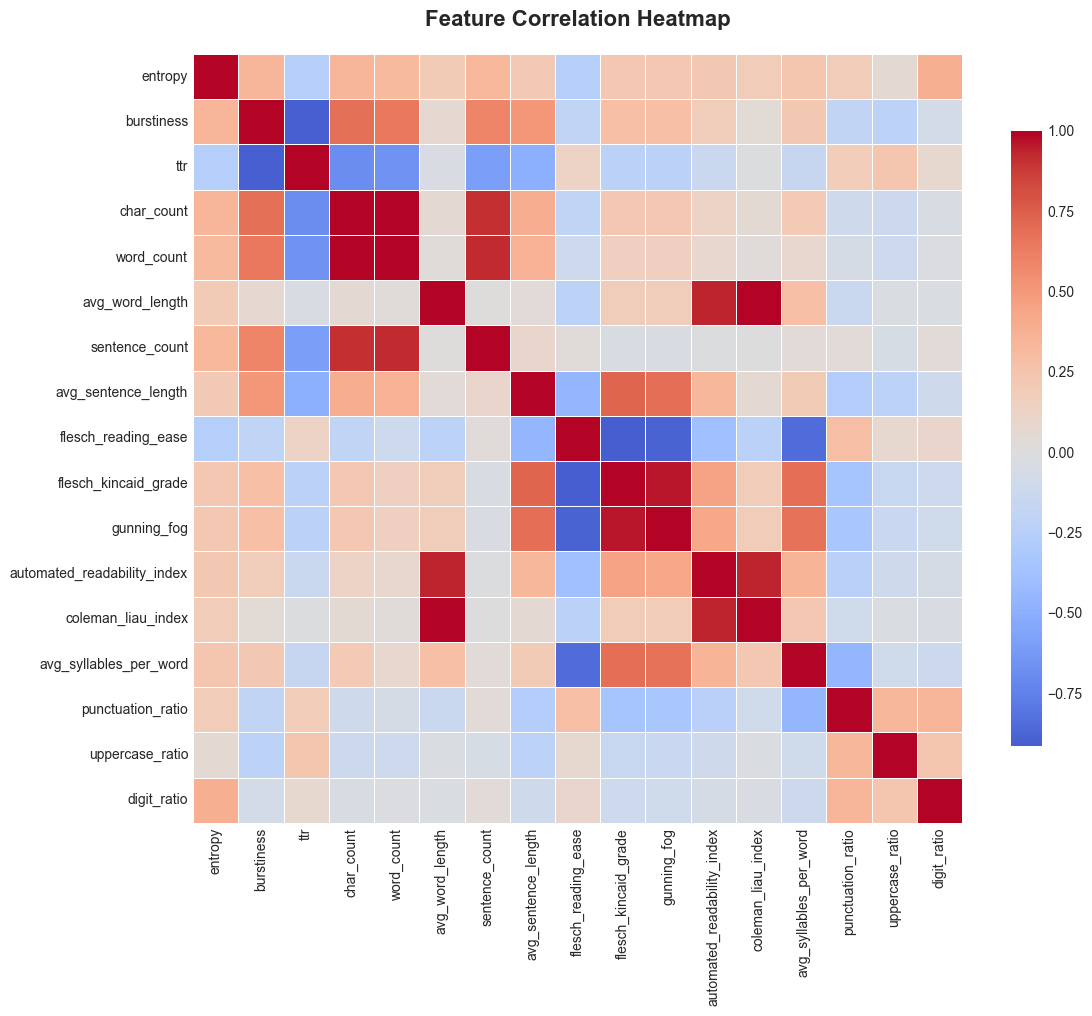


🔍 Highly correlated feature pairs (|r| > 0.8):

   burstiness                     <-> ttr                           : -0.903
   char_count                     <-> word_count                    :  0.987
   char_count                     <-> sentence_count                :  0.903
   word_count                     <-> sentence_count                :  0.921
   avg_word_length                <-> automated_readability_index   :  0.938
   avg_word_length                <-> coleman_liau_index            :  0.989
   flesch_reading_ease            <-> flesch_kincaid_grade          : -0.915
   flesch_reading_ease            <-> gunning_fog                   : -0.889
   flesch_reading_ease            <-> avg_syllables_per_word        : -0.849
   flesch_kincaid_grade           <-> gunning_fog                   :  0.961
   automated_readability_index    <-> coleman_liau_index            :  0.933


In [17]:
# Feature correlation analysis
print("📊 Analyzing feature correlations...\n")

# Calculate correlation matrix for handcrafted features
correlation_df = train_df[handcrafted_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("\n🔍 Highly correlated feature pairs (|r| > 0.8):\n")
for i in range(len(correlation_df.columns)):
    for j in range(i+1, len(correlation_df.columns)):
        corr_value = correlation_df.iloc[i, j]
        if abs(corr_value) > 0.8:
            print(f"   {correlation_df.columns[i]:30s} <-> {correlation_df.columns[j]:30s}: {corr_value:6.3f}")

## 💾 Save Features and Transformers

In [18]:
print("💾 Saving features and transformers...\n")

# Create features directory
features_dir = 'data/features'
os.makedirs(features_dir, exist_ok=True)

# Save TF-IDF features
print("Saving TF-IDF features...")
from scipy.sparse import save_npz

save_npz(os.path.join(features_dir, 'X_train_tfidf.npz'), X_train_tfidf)
save_npz(os.path.join(features_dir, 'X_val_tfidf.npz'), X_val_tfidf)
save_npz(os.path.join(features_dir, 'X_test_tfidf.npz'), X_test_tfidf)

# Save handcrafted features
print("Saving handcrafted features...")
np.save(os.path.join(features_dir, 'X_train_handcrafted.npy'), X_train_handcrafted_scaled)
np.save(os.path.join(features_dir, 'X_val_handcrafted.npy'), X_val_handcrafted_scaled)
np.save(os.path.join(features_dir, 'X_test_handcrafted.npy'), X_test_handcrafted_scaled)

# Save combined features
print("Saving combined features...")
save_npz(os.path.join(features_dir, 'X_train_combined.npz'), X_train_combined)
save_npz(os.path.join(features_dir, 'X_val_combined.npz'), X_val_combined)
save_npz(os.path.join(features_dir, 'X_test_combined.npz'), X_test_combined)

# Save labels
print("Saving labels...")
np.save(os.path.join(features_dir, 'y_train.npy'), train_df['label'].values)
np.save(os.path.join(features_dir, 'y_val.npy'), val_df['label'].values)
np.save(os.path.join(features_dir, 'y_test.npy'), test_df['label'].values)

# Save transformers
print("Saving transformers...")
with open(os.path.join(features_dir, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open(os.path.join(features_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
print("Saving feature names...")
feature_info = {
    'tfidf_features': list(tfidf_vectorizer.get_feature_names_out()),
    'handcrafted_features': handcrafted_features,
    'statistical_features': stat_features,
    'linguistic_features': ling_features,
    'n_tfidf_features': X_train_tfidf.shape[1],
    'n_handcrafted_features': len(handcrafted_features),
    'n_total_features': X_train_combined.shape[1]
}

with open(os.path.join(features_dir, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f"\n✅ All features and transformers saved to: {features_dir}")

💾 Saving features and transformers...

Saving TF-IDF features...
Saving handcrafted features...
Saving combined features...
Saving labels...
Saving transformers...
Saving feature names...

✅ All features and transformers saved to: data/features


In [19]:
# List saved files
print("\n📂 Saved files:")
for file in sorted(os.listdir(features_dir)):
    file_path = os.path.join(features_dir, file)
    size = os.path.getsize(file_path) / (1024 * 1024)  # MB
    print(f"   {file:35s} - {size:6.2f} MB")


📂 Saved files:
   X_test_combined.npz                 -   7.94 MB
   X_test_handcrafted.npy              -   1.02 MB
   X_test_tfidf.npz                    -   6.97 MB
   X_train_combined.npz                -  37.24 MB
   X_train_handcrafted.npy             -   4.76 MB
   X_train_tfidf.npz                   -  32.70 MB
   X_val_combined.npz                  -   7.84 MB
   X_val_handcrafted.npy               -   1.02 MB
   X_val_tfidf.npz                     -   6.87 MB
   feature_info.json                   -   0.08 MB
   scaler.pkl                          -   0.00 MB
   tfidf_vectorizer.pkl                -   0.18 MB
   y_test.npy                          -   0.06 MB
   y_train.npy                         -   0.28 MB
   y_val.npy                           -   0.06 MB


## 📊 Final Summary

In [20]:
print("="*70)
print("📊 FEATURE ENGINEERING COMPLETE!")
print("="*70)
print(f"\n✅ Successfully extracted and saved features")
print(f"\n📈 Feature Summary:")
print(f"   TF-IDF features:      {X_train_tfidf.shape[1]:,}")
print(f"   Statistical features: {len(stat_features)}")
print(f"   Linguistic features:  {len(ling_features)}")
print(f"   Total handcrafted:    {len(handcrafted_features)}")
print(f"   Combined features:    {X_train_combined.shape[1]:,}")
print(f"\n📊 Dataset sizes:")
print(f"   Training:   {X_train_combined.shape[0]:,} samples")
print(f"   Validation: {X_val_combined.shape[0]:,} samples")
print(f"   Test:       {X_test_combined.shape[0]:,} samples")
print(f"\n💾 Saved to: {features_dir}")
print(f"\n🎯 Ready for Model Training!")
print("="*70)

📊 FEATURE ENGINEERING COMPLETE!

✅ Successfully extracted and saved features

📈 Feature Summary:
   TF-IDF features:      5,000
   Statistical features: 8
   Linguistic features:  9
   Total handcrafted:    17
   Combined features:    5,017

📊 Dataset sizes:
   Training:   36,716 samples
   Validation: 7,868 samples
   Test:       7,868 samples

💾 Saved to: data/features

🎯 Ready for Model Training!


## 🔄 Next Steps

### What We Accomplished:
- ✅ Loaded processed datasets (52,452 samples)
- ✅ Extracted TF-IDF features (5,000 features, 1-3 grams)
- ✅ Calculated statistical features (entropy, burstiness, TTR, etc.)
- ✅ Extracted linguistic features (readability scores, punctuation, etc.)
- ✅ Combined all features (5,000+ total features)
- ✅ Scaled and normalized features
- ✅ Saved feature matrices and transformers

### Next Notebook (04_traditional_models.ipynb):
1. Load feature matrices
2. Train traditional ML models:
   - Logistic Regression
   - Random Forest
   - Support Vector Machine (SVM)
   - XGBoost
3. Hyperparameter tuning
4. Cross-validation
5. Model evaluation and comparison
6. Save best models

---

**📝 Note:** Features are ready for training both traditional and deep learning models!